In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

from datetime import datetime, timedelta
import seaborn as sns

In [2]:
graph1_1 = pd.read_csv('data/VAR_42631_56896-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
graph1_2 = pd.read_csv('data/VAR_42631_56896-odecty (1).csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
graph2 = pd.read_csv('data/VAR_41494_55419-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
graph3 = pd.read_csv('data/VAR_97467_124449-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]

In [3]:
def concatenate_datasets(df1, df2, output_file_path):
    try:
        concatenated_df = pd.concat([df1, df2], ignore_index=True)

        # Save the concatenated DataFrame to a new CSV file
        concatenated_df.to_csv(output_file_path, index=False)

        print(f"Successfully concatenated into '{output_file_path}'")
        print("\nInformation about the new concatenated dataset:")
        concatenated_df.info()

    except FileNotFoundError as e:
        print(f"Error: One of the files was not found. Please check the file paths.")
        print(f"Details: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


output_file = 'data/VAR_42631_56896-odecty-full.csv'

concatenate_datasets(graph1_1, graph1_2, output_file)
graph1 = pd.read_csv(output_file)

Successfully concatenated into 'data/VAR_42631_56896-odecty-full.csv'

Information about the new concatenated dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25258 entries, 0 to 25257
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VAR_ID           25258 non-null  int64  
 1   Time of reading  25258 non-null  object 
 2   Value            25258 non-null  float64
 3   Diff.            25256 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 789.4+ KB


In [4]:
display(graph1["Time of reading"].head())

0    2025-08-29 16:50:32.0
1    2025-08-29 16:30:32.0
2    2025-08-29 16:10:32.0
3    2025-08-29 15:30:32.0
4    2025-08-29 14:50:32.0
Name: Time of reading, dtype: object

In [5]:
def index_dataset(df, time_column):
    df[time_column] = pd.to_datetime(df[time_column])
    df.sort_values(time_column, inplace=True)
    df.set_index(time_column, inplace=True)
        
index_dataset(graph1, "Time of reading")
index_dataset(graph2, "Time of reading")
index_dataset(graph3, "Time of reading")

In [6]:
display(graph1.head(20))

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:12:00,56896,24185.53,NaN
2024-08-29 00:32:00,56896,24185.64,0.11
2024-08-29 00:52:00,56896,24185.67,0.03
2024-08-29 01:12:00,56896,24185.67,0.00
2024-08-29 01:32:00,56896,24185.68,0.01
2024-08-29 01:52:00,56896,24185.69,0.01
2024-08-29 02:12:00,56896,24185.70,0.01
2024-08-29 02:32:00,56896,24185.71,0.01
2024-08-29 02:52:00,56896,24185.71,0.00


In [7]:
import os.path
if not os.path.isfile('./data/graph1_indexed.csv'):
    graph1.to_csv('graph1_indexed.csv', index=True)
if not os.path.isfile('./data/graph1_indexed.csv'):
    graph2.to_csv('graph2_indexed.csv', index=True)
if not os.path.isfile('./data/graph1_indexed.csv'):
    graph3.to_csv('graph3_indexed.csv', index=True)

In [8]:
def check_periodicity(df):
    """
    Checks for periodicity in a DataFrame's DateTimeIndex and prints a message if a
    periodic timestamp is missed.

    Args:
        df (pd.DataFrame): The DataFrame to check. Must have a DateTimeIndex.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        print("Error: DataFrame does not have a DateTimeIndex.")
        return

    # Ensure index is sorted
    df = df.sort_index()

    # Calculate time differences between consecutive rows
    time_diffs = df.index.to_series().diff()

    # Find the most common difference (periodicity)
    periodicity = time_diffs.mode()

    if periodicity.empty:
        print("Could not determine a consistent periodicity from the data.")
        return

    most_common_period = periodicity[0]
    print(f"\nDetermined a common periodicity of: {most_common_period}")

    # Find gaps larger than expected + tolerance
    missed_timestamps = time_diffs[time_diffs > most_common_period + pd.Timedelta(minutes=5)]
    missed_timestamps_num = len(missed_timestamps)

    if missed_timestamps_num > 0:
        print("\nMissed periodic timestamp(s) detected:")
        for index, diff in missed_timestamps.items():
            prev_timestamp = df.index[df.index.get_loc(index) - 1]
            current_timestamp = index
            # print(f"  - Gap of {diff} between {prev_timestamp} and {current_timestamp}")
        print(f"\nMissed {missed_timestamps_num} timestamps out of {len(df)} measurements.")
    else:
        print("\nNo missed periodic timestamps were detected.")

        
print("Periodicity for graph1:")
check_periodicity(graph1)
print("Periodicity for graph2:")
check_periodicity(graph2)
print("Periodicity for graph3:")
check_periodicity(graph3)

Periodicity for graph1:

Determined a common periodicity of: 0 days 00:20:00

Missed periodic timestamp(s) detected:

Missed 556 timestamps out of 25258 measurements.
Periodicity for graph2:

Determined a common periodicity of: 0 days 00:30:00

Missed periodic timestamp(s) detected:

Missed 26 timestamps out of 17267 measurements.
Periodicity for graph3:

Determined a common periodicity of: 0 days 00:30:02

Missed periodic timestamp(s) detected:

Missed 351 timestamps out of 16418 measurements.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_timeseries(dfs, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None,
                   labels=None):
    """
    Plots time series data from a list of DataFrames with DateTimeIndex.
    Each DataFrame is plotted as a separate line with the same style but different colors_line.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames with time series data (must have DateTimeIndex)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points per DataFrame
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values (only works with single DF)
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title
        labels (list): Custom labels for each DataFrame (if None, uses DF1, DF2, etc.)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple DataFrames
        fig = plot_timeseries([df1, df2, df3], 'Value')

        # With custom labels and plot type
        fig = plot_timeseries([original_df, resampled_df], 'Diff.', 
                             labels=['Original', 'Resampled'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries([raw_data, hourly_resampled, interpolated], 'Value',
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if not isinstance(dfs, list):
        raise ValueError("First parameter must be a list of DataFrames")

    if len(dfs) == 0:
        raise ValueError("List of DataFrames cannot be empty")

    # Check that all DataFrames have DateTimeIndex
    for i, df in enumerate(dfs):
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError(f"DataFrame {i} must have a DateTimeIndex")
        if value_column not in df.columns:
            raise ValueError(f"Column '{value_column}' not found in DataFrame {i}")

    # Default labels if not provided
    if labels is None:
        labels = [f"DF{i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Number of labels must match number of DataFrames")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(dfs) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 DataFrames, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(dfs)))

    # Prepare DataFrames
    dfs_plot = []
    total_points = 0

    for i, df in enumerate(dfs):
        # Work on a copy
        df_plot = df.copy().sort_index()

        # Filter by date range
        if date_range:
            start_date, end_date = date_range
            df_plot = df_plot.loc[start_date:end_date]

        # Downsample if requested
        if sample_rate and len(df_plot) > sample_rate:
            step = max(1, len(df_plot)//sample_rate)
            df_plot = df_plot.iloc[::step]

        dfs_plot.append(df_plot)
        total_points += len(df_plot)
        print(f"DataFrame {i+1} ({labels[i]}): {len(df_plot)} points")

    if date_range:
        print(f"Filtered to date range: {total_points} total points")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({total_points:,} total points)"

    # Plot each DataFrame
    for i, (df_plot, label, color_line, color_scatter) in enumerate(zip(dfs_plot, labels, colors_line, colors_scatter)):
        if len(df_plot) == 0:
            continue

        # Plot types - all DataFrames use same style but different colors_line
        if plot_type == 'line':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot.index, df_plot[value_column],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot.index, df_plot[value_column],
                       s=1, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            df_resampled = df_plot[value_column].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"DataFrame {i+1} resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values (only works with single DataFrame for backwards compatibility)
    if highlight_filled and filled_df is not None and len(dfs) == 1:
        if not isinstance(filled_df.index, pd.DatetimeIndex):
            raise ValueError("filled_df must also have a DateTimeIndex")
        filled_copy = filled_df.copy().sort_index()

        # Find timestamps in filled_df but missing in original df
        new_times = filled_copy.index.difference(dfs[0].index)

        if not new_times.empty:
            filled_only = filled_copy.loc[new_times]
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only.loc[start_date:end_date]

            if not filled_only.empty:
                ax.scatter(filled_only.index, filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple DataFrames
    stats_lines = []
    for i, (df_plot, label) in enumerate(zip(dfs_plot, labels)):
        if len(df_plot) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {df_plot[value_column].min():.2f}")
            stats_lines.append(f"  Max: {df_plot[value_column].max():.2f}")
            stats_lines.append(f"  Mean: {df_plot[value_column].mean():.2f}")
            stats_lines.append(f"  Std: {df_plot[value_column].std():.2f}")
            if i < len(dfs_plot) - 1:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of DataFrames
    font_size = max(8, min(10, 10 - len(dfs) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    #return fig

# Convenience function for common use cases
def compare_preprocessing_results(original_df, resampled_df, interpolated_df=None, 
                                 value_column='Value', **kwargs):
    """
    Convenience function to compare original, resampled, and optionally interpolated data.

    Args:
        original_df: Original water meter data
        resampled_df: Resampled hourly data  
        interpolated_df: Optional interpolated data
        value_column: Column to plot
        **kwargs: Additional arguments passed to plot_timeseries
    """
    dfs = [original_df, resampled_df]
    labels = ['Original', 'Resampled']

    if interpolated_df is not None:
        dfs.append(interpolated_df)
        labels.append('Interpolated')

    return plot_timeseries(dfs, value_column, labels=labels, 
                          title=f'Data Preprocessing Comparison - {value_column}',
                          **kwargs)


DataFrame 1 (DF1): 25258 points


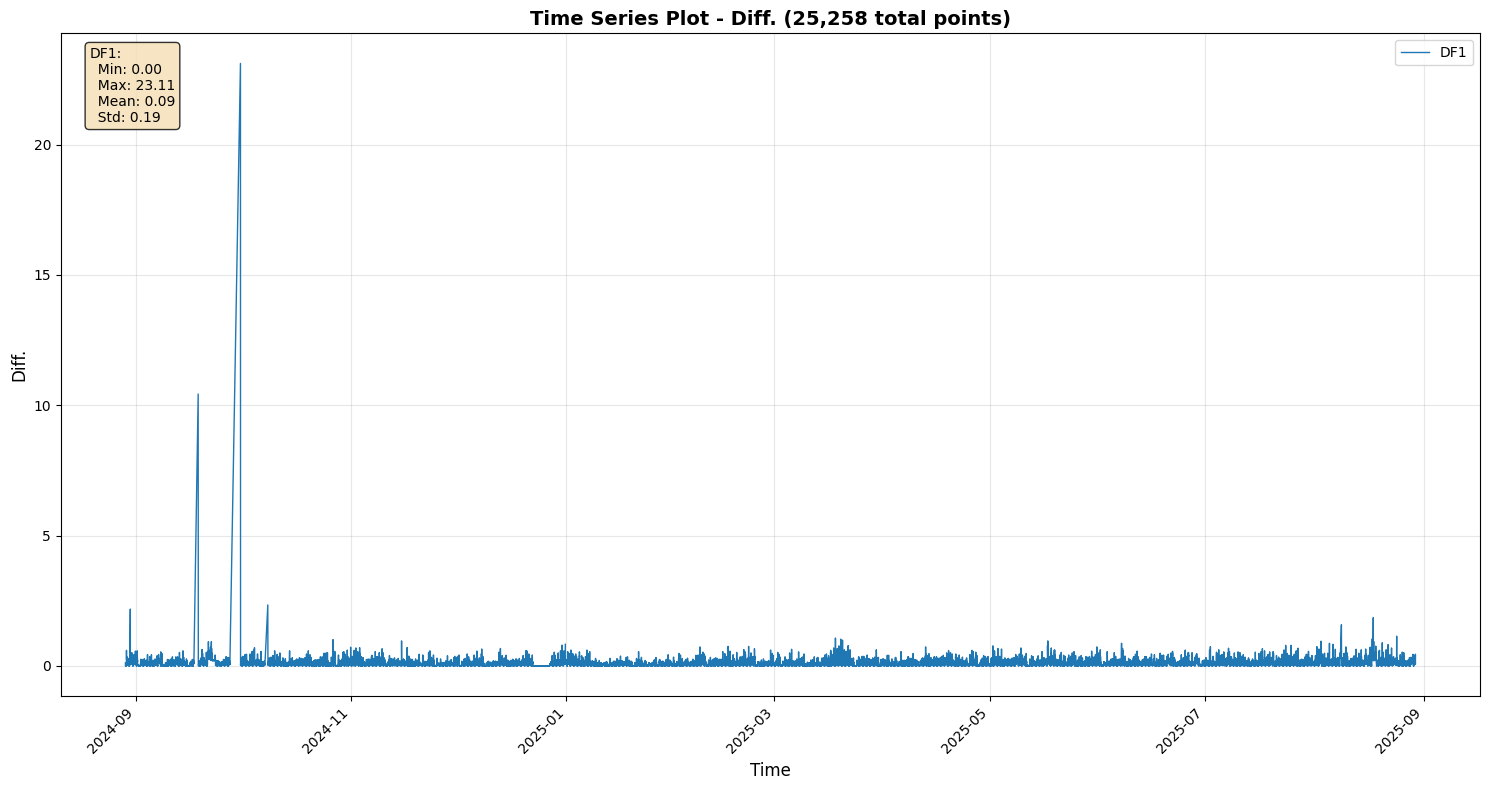

In [10]:
plot_timeseries([graph1], value_column="Diff.")

DataFrame 1 (DF1): 25258 points


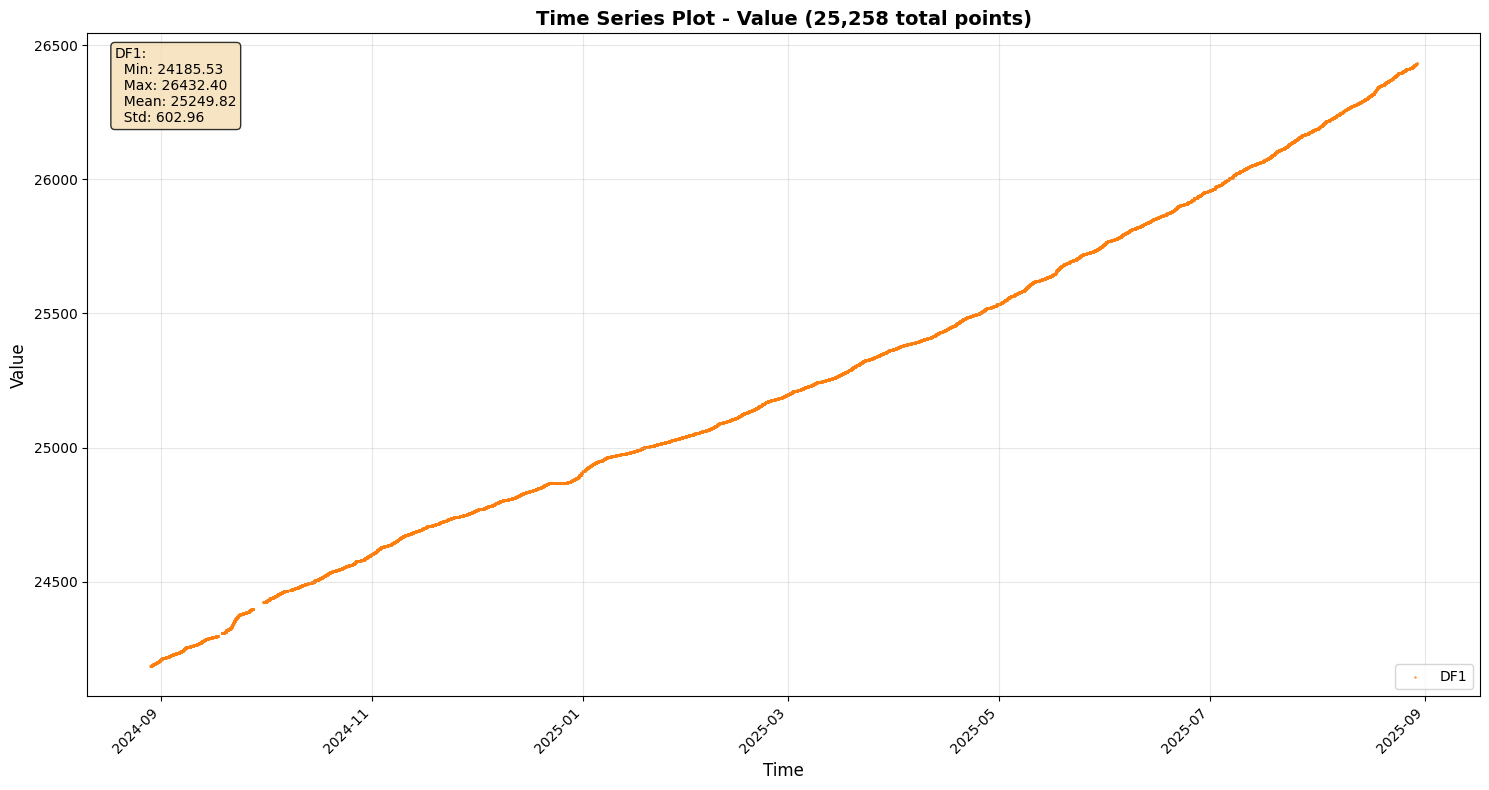

In [11]:
plot_timeseries([graph1], value_column="Value", plot_type="scatter")

DataFrame 1 (DF1): 145 points
Filtered to date range: 145 total points


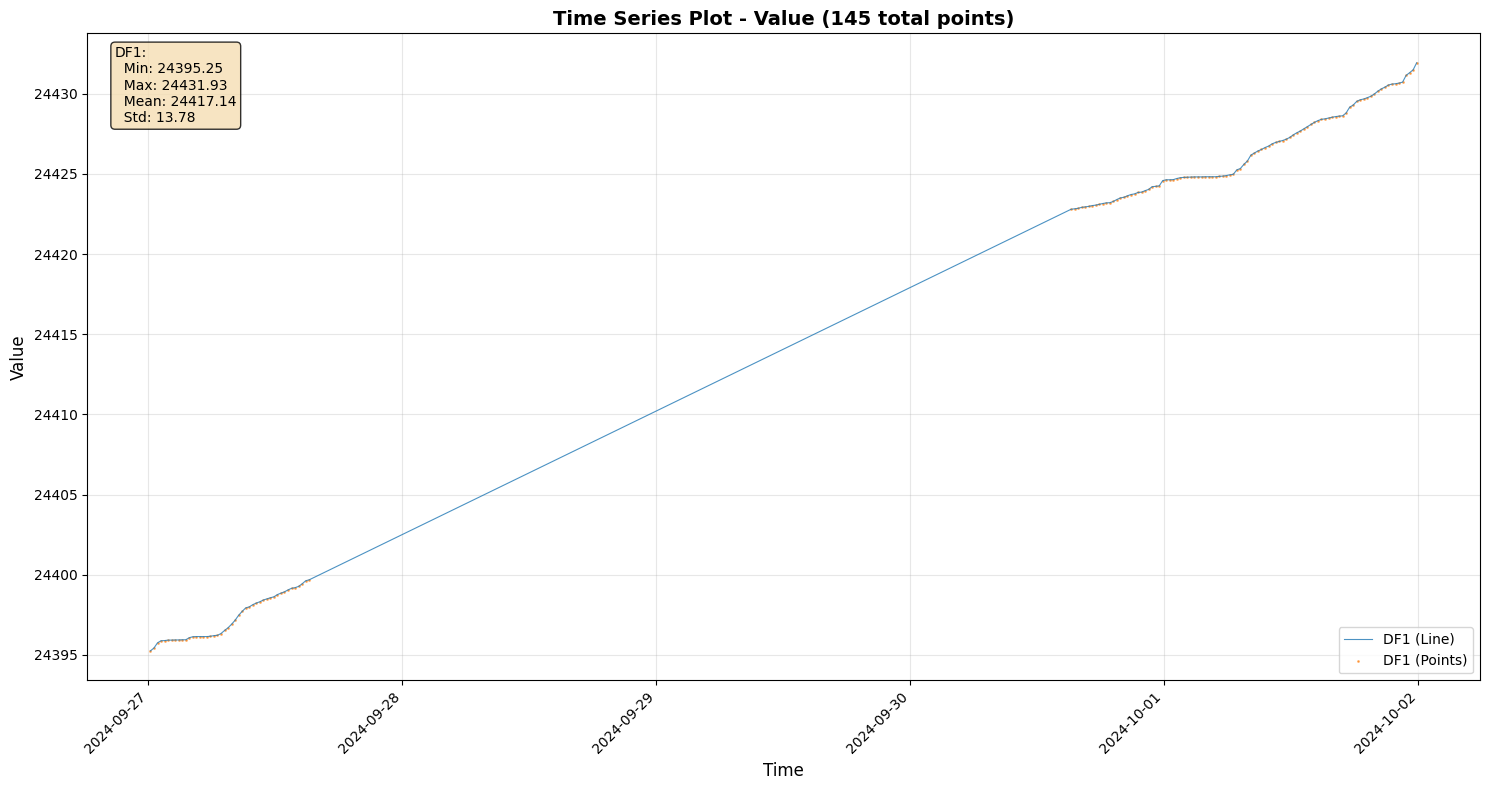

In [12]:
plot_timeseries([graph1], value_column="Value", date_range=("2024-09-27", "2024-10-1"), plot_type="both")

DataFrame 1 (DF1): 145 points
Filtered to date range: 145 total points


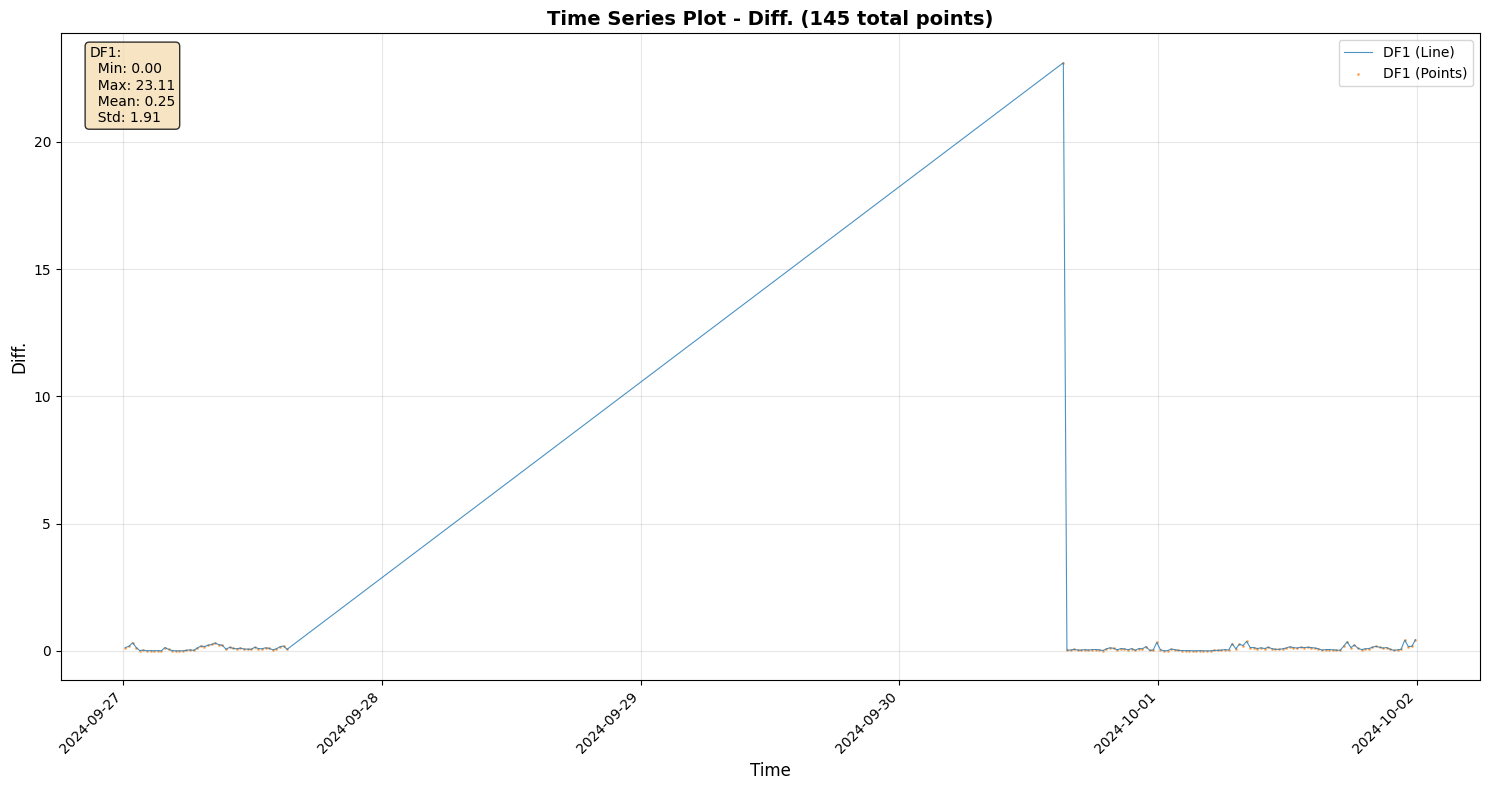

In [13]:
plot_timeseries([graph1], value_column="Diff.", date_range=("2024-09-27", "2024-10-1"), plot_type="both")

## Average per hour

In [14]:
import pandas as pd
import numpy as np
from typing import Optional, Literal

def resample_to_hourly_values(df: pd.DataFrame, 
                             sampling_method: Literal['last', 'first', 'nearest_to_hour'] = 'last',
                             drop_empty_hours: bool = True, 
                             fill_method: Optional[Literal['forward', 'ffill', 'backward', 'bfill', 'interpolate']] = None,
                             add_metadata: bool = False) -> pd.DataFrame:
    """
    Resample water meter data to hourly intervals by selecting actual values (not averages)
    and recomputing differences. Optimized for anomaly detection in water consumption data.

    This function is specifically designed for water meter data where:
    - Values are cumulative readings
    - Diff. represents consumption between readings
    - Sensors send data at irregular intervals (e.g., every 20-30 minutes)
    - Missing data is common and needs to be handled appropriately

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with datetime index (Time of reading) and columns 'Value' and 'Diff.'
        - Value: Cumulative water meter reading
        - Diff.: Consumption since previous reading

    sampling_method : {'last', 'first', 'nearest_to_hour'}, default 'last'
        Method to select value within each hour:
        - 'last': Take the last reading in each hour (recommended for cumulative data)
        - 'first': Take the first reading in each hour
        - 'nearest_to_hour': Take reading closest to the top of each hour

    drop_empty_hours : bool, default True
        If True, removes hours with no data (all NaN values)

    fill_method : {'forward', 'ffill', 'backward', 'bfill', 'interpolate'} or None, default None
        Method to fill missing hourly values:
        - 'forward'/'ffill': Forward fill (carry last observation forward)
        - 'backward'/'bfill': Backward fill 
        - 'interpolate': Linear interpolation based on time
        - None: Keep missing values as NaN

    add_metadata : bool, default False
        If True, adds metadata columns useful for anomaly detection:
        - 'readings_count': Number of original readings used for this hour
        - 'time_gap': Time gap from previous hourly reading (in hours)
        - 'interpolated': Boolean indicating if value was interpolated/filled

    Returns:
    --------
    pd.DataFrame
        DataFrame with hourly datetime index, sampled 'Value' column, and recomputed 'Diff.' column.
        If add_metadata=True, includes additional metadata columns.

    Raises:
    -------
    TypeError
        If df is not a pandas DataFrame
    ValueError
        If required columns are missing or sampling_method is invalid

    Examples:
    ---------
    Basic usage:
    >>> hourly_data = resample_to_hourly_values(df, sampling_method='last')

    With interpolation and metadata for anomaly detection:
    >>> hourly_data = resample_to_hourly_values(df, 
    ...                                        sampling_method='last',
    ...                                        fill_method='interpolate',
    ...                                        add_metadata=True)

    Notes:
    ------
    - For cumulative water meter readings, 'last' sampling method is typically preferred
    - The recomputed Diff. values represent hourly consumption amounts
    - Metadata is particularly useful for identifying potential anomalies in data collection
    - Handle missing data carefully as it can affect anomaly detection algorithms
    """

    # Input validation
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")

    required_columns = ['Value', 'Diff.']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    # Ensure the index is datetime type
    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except Exception as e:
            raise ValueError(f"Could not convert index to datetime: {e}")

    # Create a copy and sort to ensure chronological order
    df_copy = df[required_columns].copy().sort_index()

    # Sample values based on the specified method
    if sampling_method == 'last':
        # Take the last reading in each hour (most recent cumulative value)
        hourly_values = df_copy.resample('h')['Value'].last()
        if add_metadata:
            readings_count = df_copy.resample('h').size()

    elif sampling_method == 'first':
        # Take the first reading in each hour
        hourly_values = df_copy.resample('h')['Value'].first()
        if add_metadata:
            readings_count = df_copy.resample('h').size()

    elif sampling_method == 'nearest_to_hour':
        # Take the reading closest to the top of each hour
        def get_nearest_to_hour(group):
            if len(group) == 0:
                return np.nan
            # Calculate minutes from the top of the hour for each reading
            minutes_from_hour = group.index.minute + group.index.second / 60
            # Find the reading closest to minute 0 (top of hour)
            closest_idx = np.argmin(minutes_from_hour)
            return group.iloc[closest_idx]

        hourly_values = df_copy.resample('h')['Value'].apply(get_nearest_to_hour)
        if add_metadata:
            readings_count = df_copy.resample('h').size()
    else:
        raise ValueError("sampling_method must be 'first', 'last', or 'nearest_to_hour'")

    # Create DataFrame with sampled values
    hourly_df = pd.DataFrame({'Value': hourly_values})

    # Add metadata before any modifications
    if add_metadata:
        hourly_df['readings_count'] = readings_count
        hourly_df['interpolated'] = False  # Will be updated if fill_method is used

    # Track which values are missing before filling (for metadata)
    missing_mask = hourly_df['Value'].isnull()

    # Handle empty hours
    if drop_empty_hours:
        if add_metadata:
            # Only drop hours where there are truly no readings (not just NaN values)
            drop_mask = hourly_df['Value'].isnull() & (hourly_df['readings_count'] == 0)
            hourly_df = hourly_df[~drop_mask]
            # Update missing_mask after dropping
            missing_mask = missing_mask.loc[hourly_df.index]
        else:
            hourly_df = hourly_df.dropna()

    # Apply fill method if specified
    if fill_method in ['forward', 'ffill']:
        filled_values = hourly_df['Value'].ffill()
        if add_metadata:
            # Mark which values were forward filled
            hourly_df.loc[:, 'interpolated'] = hourly_df['interpolated'] | (missing_mask & filled_values.notnull())
        hourly_df['Value'] = filled_values

    elif fill_method in ['backward', 'bfill']:
        filled_values = hourly_df['Value'].bfill()
        if add_metadata:
            # Mark which values were backward filled
            hourly_df.loc[:, 'interpolated'] = hourly_df['interpolated'] | (missing_mask & filled_values.notnull())
        hourly_df['Value'] = filled_values

    elif fill_method == 'interpolate':
        filled_values = hourly_df['Value'].interpolate(method='time')
        if add_metadata:
            # Mark which values were interpolated
            hourly_df.loc[:, 'interpolated'] = hourly_df['interpolated'] | (missing_mask & filled_values.notnull())
        hourly_df['Value'] = filled_values

    # Recompute Diff. as difference between consecutive hourly values
    # This represents the consumption during each hour
    hourly_df['Diff.'] = hourly_df['Value'].diff()

    # Add time gap information for anomaly detection
    if add_metadata:
        # Calculate time gap between consecutive readings in hours
        time_diffs = hourly_df.index.to_series().diff()
        hourly_df['time_gap'] = time_diffs.dt.total_seconds() / 3600

    return hourly_df


def analyze_resampling_quality(original_df: pd.DataFrame, 
                              resampled_df: pd.DataFrame, 
                              print_summary: bool = True) -> dict:
    """
    Analyze the quality of resampling for anomaly detection purposes.

    Parameters:
    -----------
    original_df : pd.DataFrame
        Original water meter data
    resampled_df : pd.DataFrame  
        Resampled hourly data (with metadata)
    print_summary : bool, default True
        Whether to print summary statistics

    Returns:
    --------
    dict
        Dictionary containing quality metrics
    """

    metrics = {}

    # Basic statistics
    metrics['original_readings'] = len(original_df)
    metrics['hourly_readings'] = len(resampled_df)
    metrics['data_reduction_ratio'] = len(original_df) / len(resampled_df)

    # Time coverage
    original_duration = (original_df.index.max() - original_df.index.min()).total_seconds() / 3600
    resampled_duration = (resampled_df.index.max() - resampled_df.index.min()).total_seconds() / 3600
    metrics['original_duration_hours'] = original_duration
    metrics['resampled_duration_hours'] = resampled_duration

    if 'interpolated' in resampled_df.columns:
        metrics['interpolated_hours'] = resampled_df['interpolated'].sum()
        metrics['interpolation_rate'] = metrics['interpolated_hours'] / len(resampled_df)

    if 'readings_count' in resampled_df.columns:
        metrics['avg_readings_per_hour'] = resampled_df['readings_count'].mean()
        metrics['hours_with_multiple_readings'] = (resampled_df['readings_count'] > 1).sum()
        metrics['hours_with_no_readings'] = (resampled_df['readings_count'] == 0).sum()

    if 'time_gap' in resampled_df.columns:
        metrics['max_time_gap_hours'] = resampled_df['time_gap'].max()
        metrics['avg_time_gap_hours'] = resampled_df['time_gap'].mean()

    # Consumption statistics
    metrics['total_consumption_original'] = original_df['Diff.'].sum()
    metrics['total_consumption_resampled'] = resampled_df['Diff.'].sum()
    metrics['consumption_preservation_ratio'] = (
        metrics['total_consumption_resampled'] / metrics['total_consumption_original']
        if metrics['total_consumption_original'] != 0 else np.nan
    )

    if print_summary:
        print("=== Resampling Quality Analysis ===")
        print(f"Data reduction: {metrics['original_readings']} → {metrics['hourly_readings']} "
              f"({metrics['data_reduction_ratio']:.2f}x reduction)")
        print(f"Duration: {metrics['original_duration_hours']:.1f} → {metrics['resampled_duration_hours']:.1f} hours")

        if 'interpolated_hours' in metrics:
            print(f"Interpolated hours: {metrics['interpolated_hours']} "
                  f"({metrics['interpolation_rate']:.1%})")

        if 'avg_readings_per_hour' in metrics:
            print(f"Average readings per hour: {metrics['avg_readings_per_hour']:.2f}")
            print(f"Hours with multiple readings: {metrics['hours_with_multiple_readings']}")
            print(f"Hours with no original readings: {metrics['hours_with_no_readings']}")

        if 'max_time_gap_hours' in metrics:
            print(f"Max time gap: {metrics['max_time_gap_hours']:.2f} hours")

        print(f"Total consumption preservation: {metrics['consumption_preservation_ratio']:.4f}")

    return metrics


# Example usage and best practices for anomaly detection
def example_usage():
    """
    Example usage for water meter anomaly detection preprocessing.
    """

    # Example: Load your water meter data
    # df = pd.read_csv('water_meter_data.csv', index_col='Time of reading', parse_dates=True)

    # For demonstration, create sample data
    np.random.seed(42)
    dates = pd.date_range('2024-01-01', periods=1000, freq='25min')
    base_value = 1000
    values = base_value + np.cumsum(np.random.exponential(2, len(dates)))
    diffs = np.diff(values, prepend=values[0])

    df = pd.DataFrame({
        'Value': values,
        'Diff.': diffs
    }, index=dates)

    print("Original data sample:")
    print(df.head())
    print(f"Shape: {df.shape}")

    # Resample for anomaly detection
    hourly_data = resample_to_hourly_values(
        df, 
        sampling_method='first',  # Use last reading in each hour
        fill_method='interpolate',  # Interpolate missing hours
        add_metadata=True  # Include metadata for anomaly detection
    )

    print("\nResampled data:")
    print(hourly_data.head())

    # Analyze quality
    quality_metrics = analyze_resampling_quality(df, hourly_data)

    return df, hourly_data, quality_metrics

#if __name__ == "__main__":
#    example_usage()


In [15]:
hourly_df_first = resample_to_hourly_values(
    graph1, 
    sampling_method='first',  
    fill_method=None, 
    add_metadata=True  
)

print("Original data sample:")
print(graph1.head())
print(f"Shape: {graph1.shape}")

print("\nResampled data:")
print(hourly_df_first.head())
print(f"Shape: {hourly_df_first.shape}")

quality_metrics = analyze_resampling_quality(graph1, hourly_df_first)

Original data sample:
                     VAR_ID     Value  Diff.
Time of reading                             
2024-08-29 00:12:00   56896  24185.53    NaN
2024-08-29 00:32:00   56896  24185.64   0.11
2024-08-29 00:52:00   56896  24185.67   0.03
2024-08-29 01:12:00   56896  24185.67   0.00
2024-08-29 01:32:00   56896  24185.68   0.01
Shape: (25258, 3)

Resampled data:
                        Value  readings_count  interpolated  Diff.  time_gap
Time of reading                                                             
2024-08-29 00:00:00  24185.53               3         False    NaN       NaN
2024-08-29 01:00:00  24185.67               3         False   0.14       1.0
2024-08-29 02:00:00  24185.70               3         False   0.03       1.0
2024-08-29 03:00:00  24185.72               3         False   0.02       1.0
2024-08-29 04:00:00  24185.74               3         False   0.02       1.0
Shape: (8623, 5)
=== Resampling Quality Analysis ===
Data reduction: 25258 → 8623 (2.93x 

In [16]:
hourly_df_closest = resample_to_hourly_values(
    graph1, 
    sampling_method="nearest_to_hour",  
    fill_method=None, 
    add_metadata=True  
)

print("Original data sample:")
print(graph1.head())
print(f"Shape: {graph1.shape}")

print("\nResampled data:")
print(hourly_df_closest.head())
print(f"Shape: {hourly_df_closest.shape}")

quality_metrics = analyze_resampling_quality(graph1, hourly_df_closest)

Original data sample:
                     VAR_ID     Value  Diff.
Time of reading                             
2024-08-29 00:12:00   56896  24185.53    NaN
2024-08-29 00:32:00   56896  24185.64   0.11
2024-08-29 00:52:00   56896  24185.67   0.03
2024-08-29 01:12:00   56896  24185.67   0.00
2024-08-29 01:32:00   56896  24185.68   0.01
Shape: (25258, 3)

Resampled data:
                        Value  readings_count  interpolated  Diff.  time_gap
Time of reading                                                             
2024-08-29 00:00:00  24185.53               3         False    NaN       NaN
2024-08-29 01:00:00  24185.67               3         False   0.14       1.0
2024-08-29 02:00:00  24185.70               3         False   0.03       1.0
2024-08-29 03:00:00  24185.72               3         False   0.02       1.0
2024-08-29 04:00:00  24185.74               3         False   0.02       1.0
Shape: (8623, 5)
=== Resampling Quality Analysis ===
Data reduction: 25258 → 8623 (2.93x 

DataFrame 1 (original): 25258 points
DataFrame 2 (resampled): 8623 points


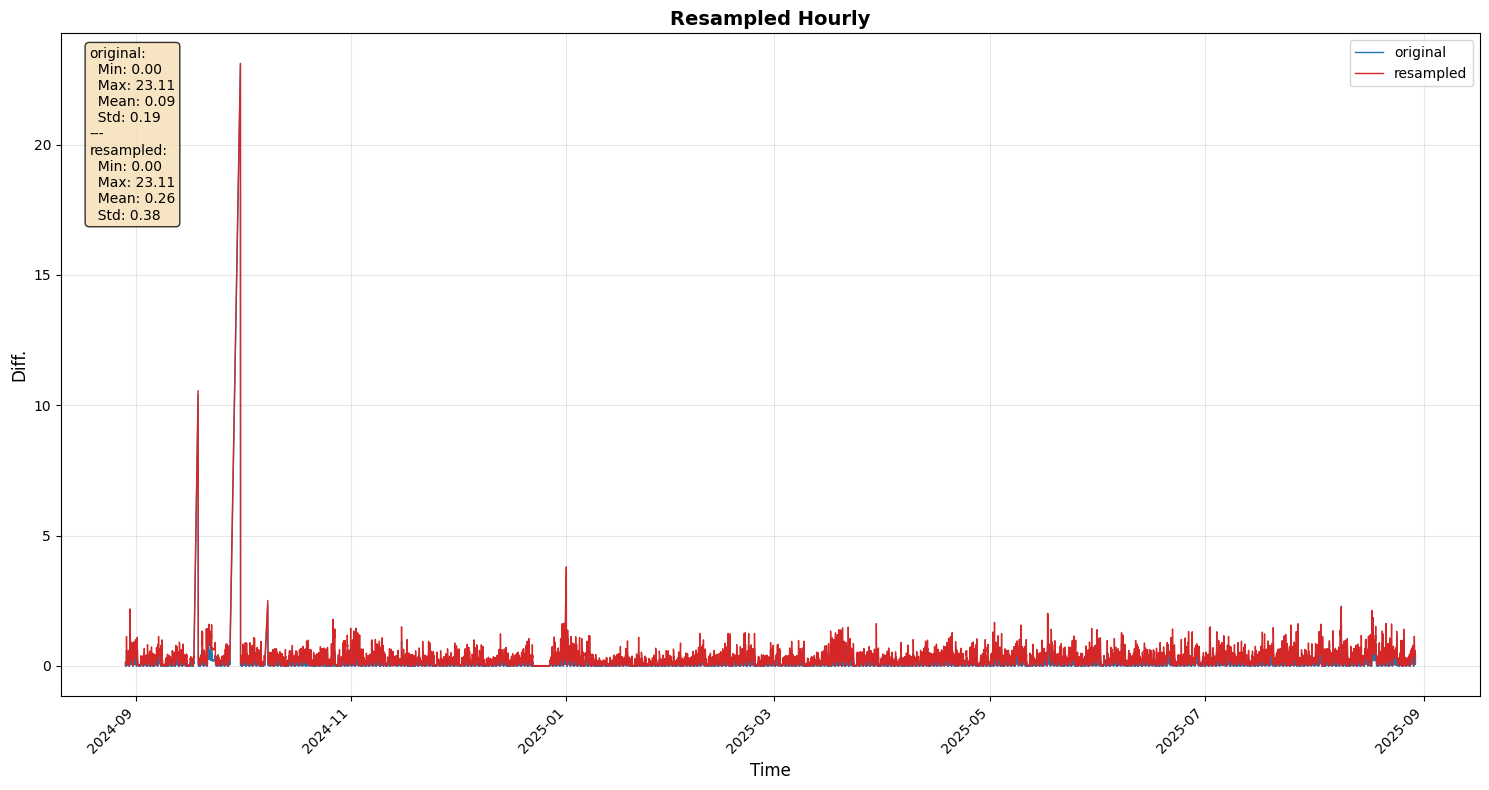

In [17]:
plot_timeseries([graph1, hourly_df_first], value_column="Diff.", title="Resampled Hourly", labels=["original", "resampled"])

DataFrame 1 (original): 25258 points
DataFrame 2 (resampled): 8623 points


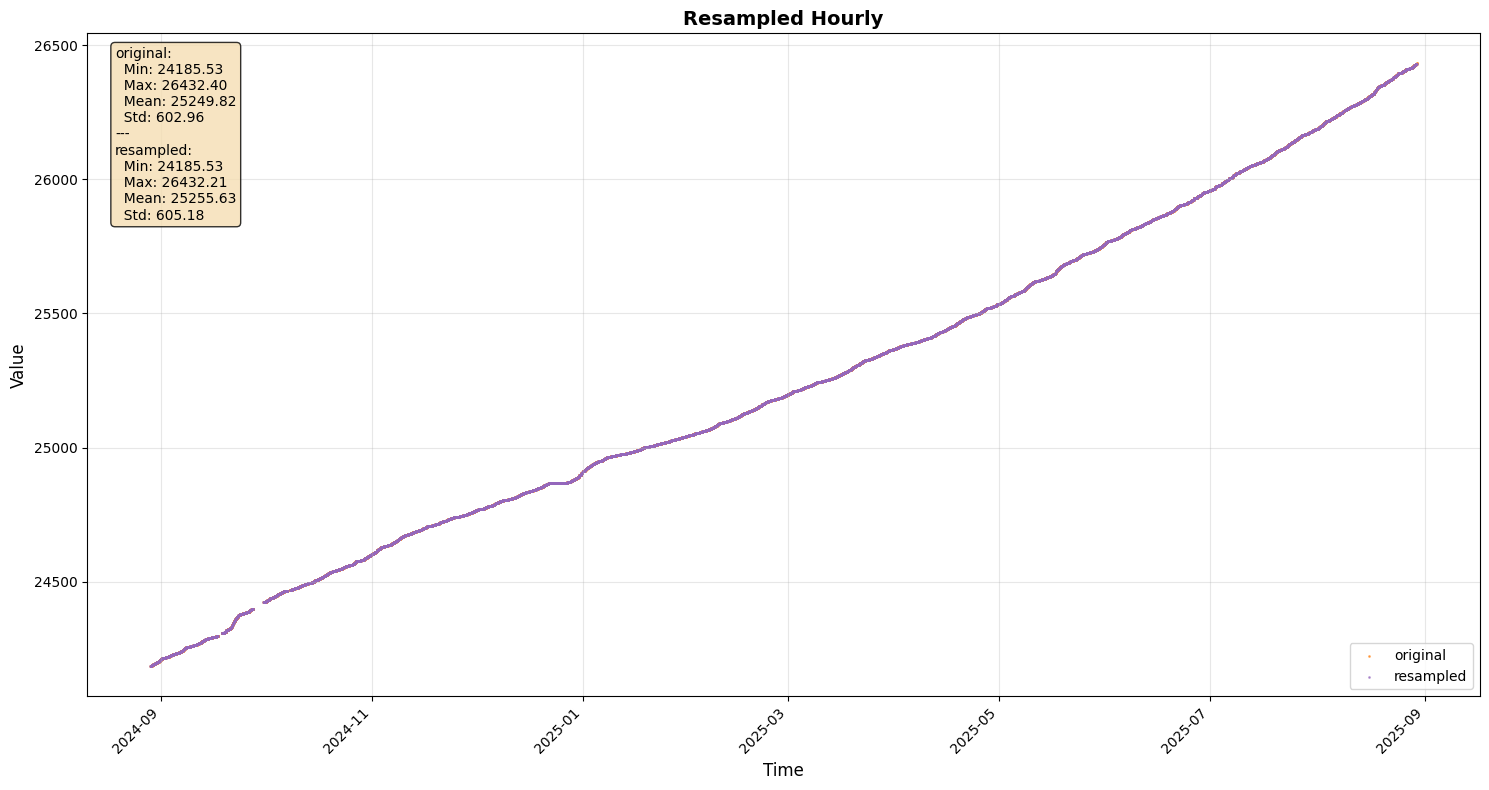

In [18]:
plot_timeseries([graph1, hourly_df_first], value_column="Value", plot_type="scatter", title="Resampled Hourly", labels=["original", "resampled"])

DataFrame 1 (original): 145 points
DataFrame 2 (resampled): 49 points
Filtered to date range: 194 total points


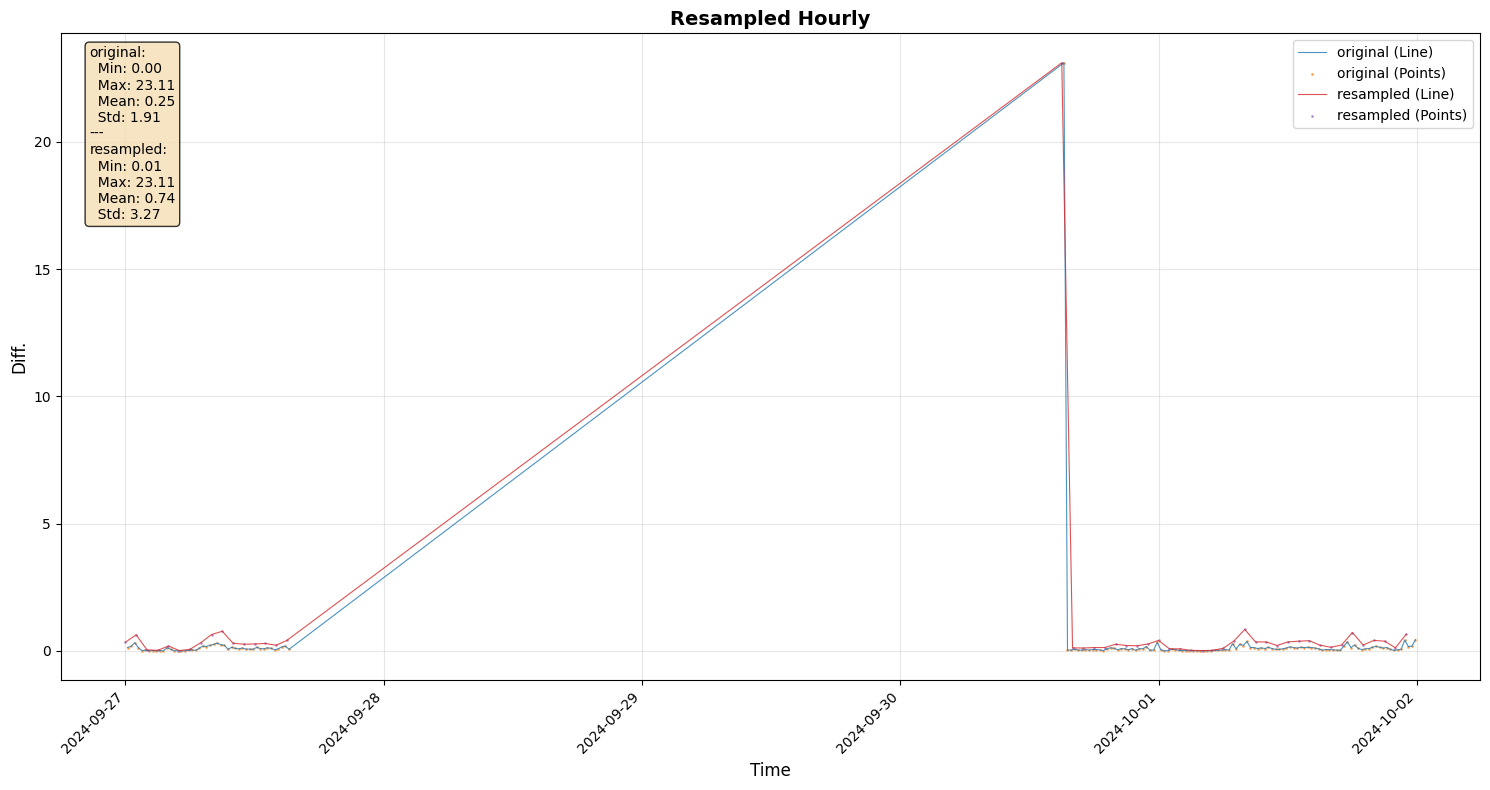

In [19]:
plot_timeseries([graph1, hourly_df_first], value_column="Diff.", date_range=("2024-09-27", "2024-10-1"), plot_type="both", title="Resampled Hourly", labels=["original", "resampled"])

DataFrame 1 (original): 360 points
DataFrame 2 (resampled): 120 points
Filtered to date range: 480 total points


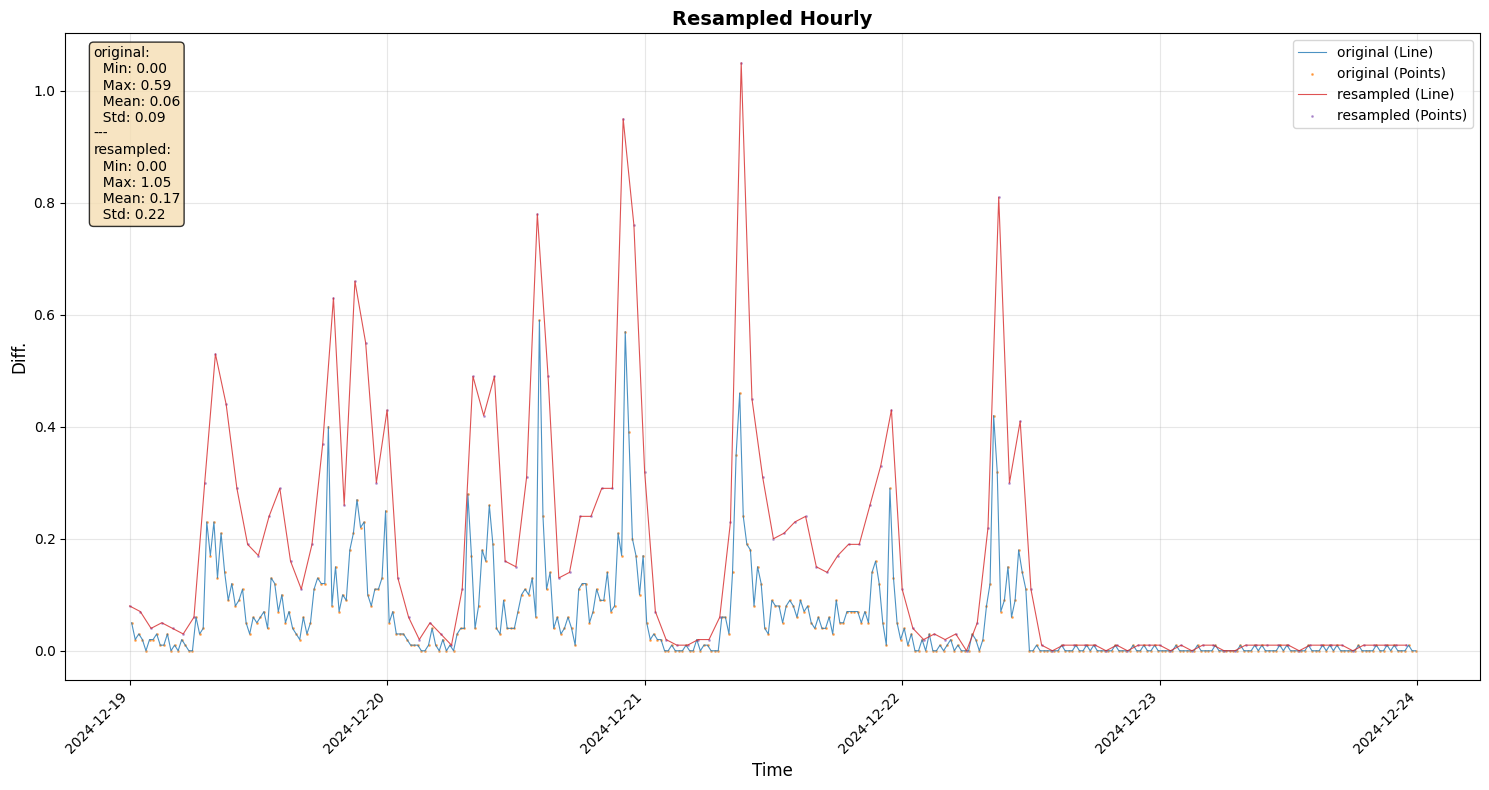

In [20]:
plot_timeseries([graph1, hourly_df_first], value_column="Diff.", date_range=("2024-12-19", "2024-12-23"), plot_type="both", title="Resampled Hourly", labels=["original", "resampled"])

DataFrame 1 (original): 360 points
DataFrame 2 (resampled): 120 points
Filtered to date range: 480 total points


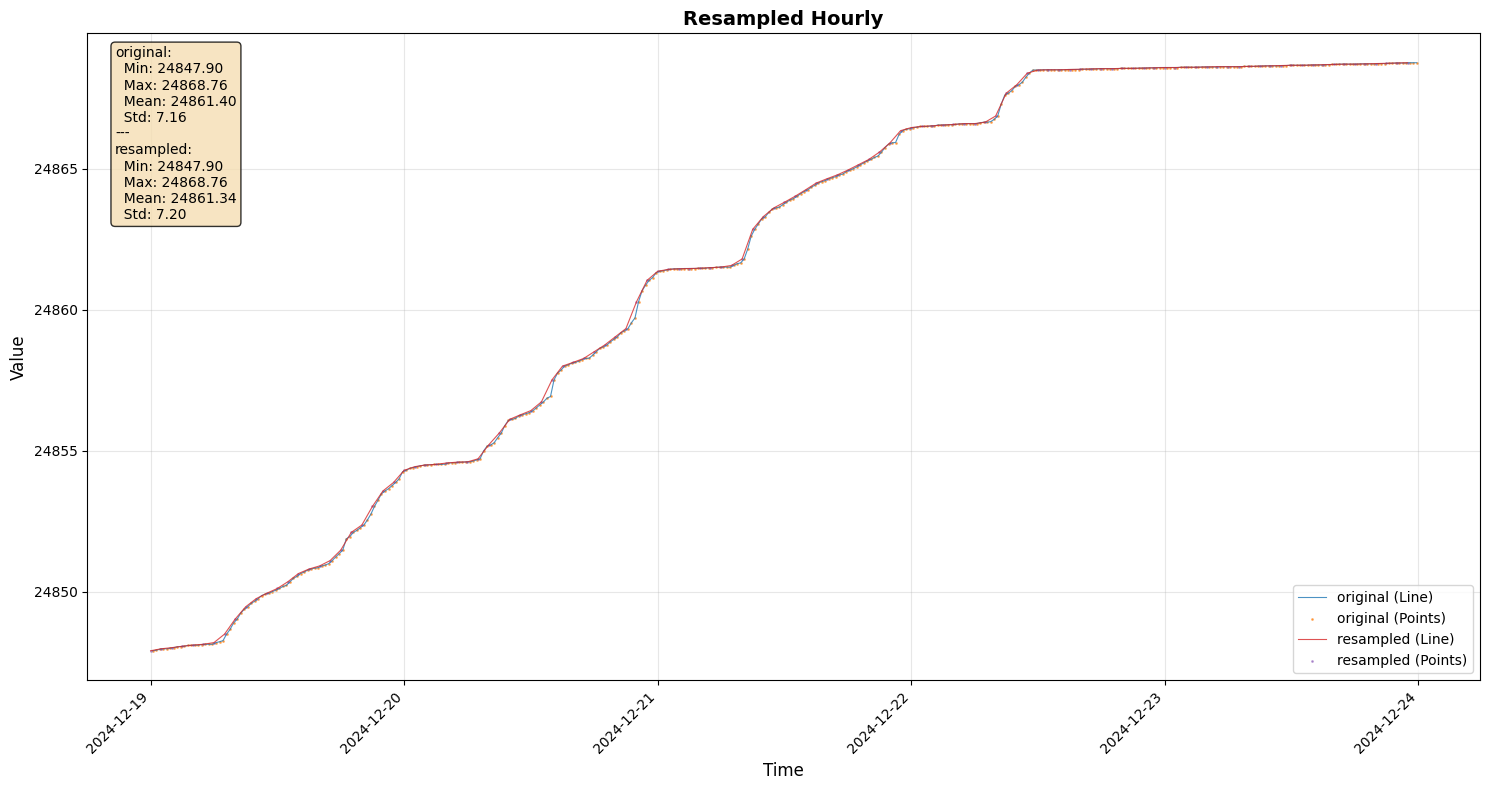

In [21]:
plot_timeseries([graph1, hourly_df_first], value_column="Value", date_range=("2024-12-19", "2024-12-23"), plot_type="both", title="Resampled Hourly", labels=["original", "resampled"])

DataFrame 1 (original): 144 points
DataFrame 2 (resampled): 48 points
Filtered to date range: 192 total points


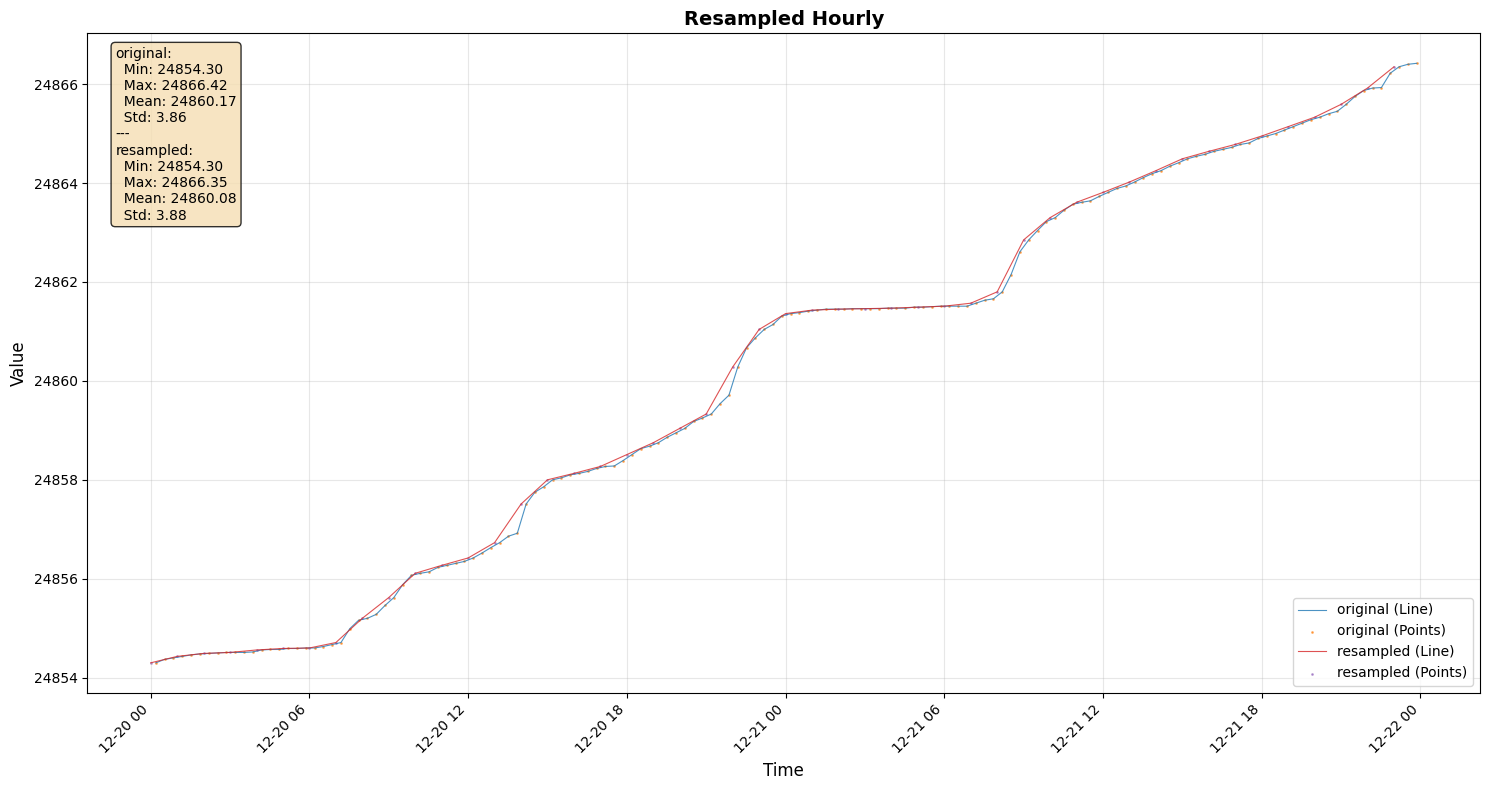

In [22]:
plot_timeseries([graph1, hourly_df_first], value_column="Value", date_range=("2024-12-20", "2024-12-21"), plot_type="both", title="Resampled Hourly", labels=["original", "resampled"])

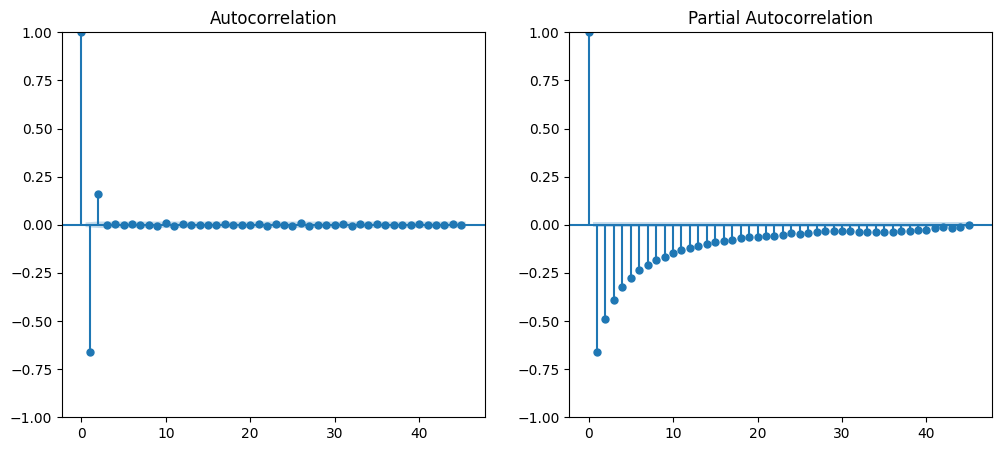

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(121)
plot_acf(graph1['Diff.'].diff().diff().dropna(), ax=plt.gca())  # diff if d=1
plt.subplot(122)
plot_pacf(graph1['Diff.'].diff().diff().dropna(), ax=plt.gca())
plt.show()

In [24]:
import pandas as pd
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fill_missing_timestamps_with_auto_arima_global(df, value_column, period_minutes=20, tolerance_minutes=5):
    """
    Fills missing timestamps in a time-indexed DataFrame using ARIMA forecasts.
    Each gap is filled in place so subsequent gaps use the imputed values.

    Args:
        df (pd.DataFrame): DataFrame with DateTimeIndex.
        value_column (str): Name of the value column to forecast.
        period_minutes (int): Expected time between readings (default 20).
        tolerance_minutes (int): Allowable tolerance for gaps (default 5).

    Returns:
        pd.DataFrame: DataFrame with missing timestamps filled.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DateTimeIndex")

    df_work = df.copy().sort_index()
    expected_period = pd.Timedelta(minutes=period_minutes)
    tolerance = pd.Timedelta(minutes=tolerance_minutes)
    gap_threshold = expected_period + tolerance

    # Step 1: Fit auto_arima on non-NaN values to get best order
    series_nonan = df_work[value_column].dropna()
    if len(series_nonan) < 10:
        print("Too few valid points to fit ARIMA. Returning original DataFrame.")
        return df_work

    print("Selecting best ARIMA model using auto_arima on full series...")
    try:
        auto_model = pm.auto_arima(
            series_nonan,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            n_jobs=-1
        )
        best_order = auto_model.order
        print("Selected ARIMA order:", best_order)
    except Exception as e:
        print(f"Error fitting auto_arima: {e}")
        return df_work

    # Step 2: Identify gaps
    gap_threshold = expected_period + tolerance

    time_diffs = df_work.index.to_series().diff()
    gaps = time_diffs[time_diffs > gap_threshold]

    if gaps.empty:
        print("No significant gaps found.")
        return df_work

    total_filled = 0

    for gap_index, gap_duration in gaps.items():
        num_missing = int(gap_duration.total_seconds() / (period_minutes * 60)) - 1
        if num_missing <= 0:
            continue

        start_time = df_work.index[df_work.index.get_loc(gap_index) - 1]
        missing_times = pd.date_range(start=start_time + expected_period, periods=num_missing, freq=f"{period_minutes}min")

        # Step 3: Fit SARIMAX on data up to this gap (including previously imputed values)
        series_before_gap = df_work.loc[:start_time, value_column].dropna().astype(float)
        if series_before_gap.empty:
            print(f"Skipping gap at {start_time} — no valid data to forecast from.")
            continue

        try:
            model = SARIMAX(
                series_before_gap,
                order=best_order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit(disp=False)
            forecasted_values = fit.get_forecast(steps=num_missing).predicted_mean.values
        except Exception as e:
            print(f"Error forecasting gap at {start_time}: {e}")
            # fallback: fill with last known value
            forecasted_values = [series_before_gap.iloc[-1]] * num_missing

        # Step 4: Insert forecasted values directly into df_work
        gap_df = pd.DataFrame({value_column: forecasted_values}, index=missing_times)

        # Keep VAR_ID if present
        if "VAR_ID" in df_work.columns:
            gap_df["VAR_ID"] = df_work["VAR_ID"].iloc[0]

        df_work = pd.concat([df_work, gap_df]).sort_index()
        total_filled += num_missing
        print(f"Filled gap starting at {start_time} with {num_missing} timestamps with values {forecasted_values}")

    print(f"Successfully filled {total_filled} missing timestamps across {len(gaps)} gaps.")
    return df_work


In [25]:
import pandas as pd
import numpy as np

def _check_time_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex for time series imputation.")

import pandas as pd
import numpy as np

def _check_time_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex for time series imputation.")

def create_missing_rows_and_interpolate(df, column, period_minutes=20, tolerance_minutes=5, method='time'):
    """
    1. Identify gaps in timestamps (missing sensor readings)
    2. Create rows for missing timestamps with NaN values  
    3. Interpolate the missing values
    4. Print detailed information about what was interpolated
    """
    _check_time_index(df)
    df_work = df.copy().sort_index()
    
    # Step 1: Define gap detection parameters
    expected_period = pd.Timedelta(minutes=period_minutes)
    tolerance = pd.Timedelta(minutes=tolerance_minutes)
    gap_threshold = expected_period + tolerance
    
    # Step 2: Identify gaps
    time_diffs = df_work.index.to_series().diff()
    gaps = time_diffs[time_diffs > gap_threshold]
    
    if gaps.empty:
        print("No significant gaps found.")
        # Still check for existing NaN values
        existing_nans = df_work[column].isna().sum()
        if existing_nans > 0:
            print(f"Found {existing_nans} existing NaN values to interpolate")
            df_work[column] = df_work[column].interpolate(method=method)
        return df_work
    
    print(f"Found {len(gaps)} gaps to fill")
    
    # Step 3: Create missing timestamp rows and track them
    new_rows = []
    added_timestamps = []
    total_filled = 0
    
    for gap_index, gap_duration in gaps.items():
        num_missing = int(gap_duration.total_seconds() / (period_minutes * 60)) - 1
        if num_missing <= 0:
            continue
            
        gap_loc = df_work.index.get_loc(gap_index)
        start_time = df_work.index[gap_loc - 1]
        
        missing_times = pd.date_range(
            start=start_time + expected_period, 
            periods=num_missing, 
            freq=f"{period_minutes}min"
        )
        
        print(f"Gap at {gap_index}: Adding {num_missing} timestamps between {start_time} and {gap_index}")
        
        for missing_time in missing_times:
            new_row = pd.Series(index=df_work.columns, dtype=float)
            new_row.name = missing_time
            new_row[column] = np.nan
            new_rows.append(new_row)
            added_timestamps.append(missing_time)
            
        total_filled += num_missing
    
    if new_rows:
        # Step 4: Add the new rows to the dataframe
        new_rows_df = pd.DataFrame(new_rows)
        df_complete = pd.concat([df_work, new_rows_df]).sort_index()
        print(f"✓ Added {total_filled} missing timestamps")
    else:
        df_complete = df_work
        added_timestamps = []
    
    # Step 5: Count NaN values before interpolation
    nan_count_before = df_complete[column].isna().sum()
    print(f"NaN values before interpolation: {nan_count_before}")
    
    # Step 6: Interpolate
    print(f"Applying {method} interpolation...")
    
    if method == 'time':
        df_complete[column] = df_complete[column].interpolate(method='time')
    elif method == 'cubic':
        df_complete[column] = df_complete[column].interpolate(method='cubic')
    elif method == 'spline':
        df_complete[column] = df_complete[column].interpolate(method='spline', order=3)
    elif method == 'linear':
        df_complete[column] = df_complete[column].interpolate(method='linear')
    else:
        raise ValueError("Method must be 'time', 'cubic', 'spline', or 'linear'")
    
    # Step 7: Count NaN values after interpolation
    nan_count_after = df_complete[column].isna().sum()
    interpolated_count = nan_count_before - nan_count_after
    
    print(f"NaN values after interpolation: {nan_count_after}")
    print(f"✓ Successfully interpolated {interpolated_count} values")
    
    # Step 8: Show interpolated values
    if added_timestamps:
        print(f"\n--- INTERPOLATED VALUES ---")
        print(f"{'Timestamp':<20} {'Interpolated Value':<20}")
        print("-" * 40)
        
        # Show first 10 interpolated values
        display_count = min(10, len(added_timestamps))
        for i, timestamp in enumerate(sorted(added_timestamps)[:display_count]):
            if timestamp in df_complete.index:
                value = df_complete.loc[timestamp, column]
                print(f"{timestamp.strftime('%Y-%m-%d %H:%M'):<20} {value:<20.3f}")
        
        if len(added_timestamps) > 10:
            print(f"... and {len(added_timestamps) - 10} more interpolated values")
            
        # Show some context around interpolated values
        print(f"\n--- SAMPLE CONTEXT (around first interpolated value) ---")
        if added_timestamps:
            sample_time = sorted(added_timestamps)[0]
            sample_idx = df_complete.index.get_loc(sample_time)
            
            # Show 2 values before and 2 after
            start_idx = max(0, sample_idx - 2)
            end_idx = min(len(df_complete), sample_idx + 3)
            
            context_slice = df_complete.iloc[start_idx:end_idx]
            print(f"{'Timestamp':<20} {'Value':<15} {'Status':<15}")
            print("-" * 50)
            
            for idx, (timestamp, row) in enumerate(context_slice.iterrows()):
                value = row[column]
                if timestamp in added_timestamps:
                    status = "INTERPOLATED"
                else:
                    status = "ORIGINAL"
                print(f"{timestamp.strftime('%Y-%m-%d %H:%M'):<20} {value:<15.3f} {status}")
    
    # Ensure non-negative values
    df_complete[column] = df_complete[column].clip(lower=0)
    
    print(f"\n✓ Final DataFrame: {len(df_complete)} rows (was {len(df_work)})")
    
    return df_complete


# Simpler function if you just want to add missing timestamps without interpolation
def add_missing_timestamps(df, column, period_minutes=20, tolerance_minutes=5):
    """
    Just add missing timestamp rows with NaN values (no interpolation).
    Then you can use standard pandas interpolate methods.
    """
    df_with_gaps = create_missing_rows_and_interpolate(
        df, column, period_minutes, tolerance_minutes, method='linear'
    )
    # Reset the values to NaN so you can choose your own interpolation
    time_diffs = df.index.to_series().diff()
    gaps = time_diffs[time_diffs > pd.Timedelta(minutes=period_minutes + tolerance_minutes)]
    
    # Mark newly added rows as NaN
    original_index = set(df.index)
    for idx in df_with_gaps.index:
        if idx not in original_index:
            df_with_gaps.loc[idx, column] = np.nan
            
    return df_with_gaps


In [26]:
graph1_filled = create_missing_rows_and_interpolate(graph1, "Diff.", method="cubic")
# Compare original vs filled data
#fig = detailed_plot(graph1)
#fig2 = detailed_plot(graph1_filled)
fig = compare_before_after(graph1, graph1_filled)
plt.show()

Found 556 gaps to fill
Gap at 2024-08-29 10:32:00: Adding 1 timestamps between 2024-08-29 09:52:00 and 2024-08-29 10:32:00
Gap at 2024-08-30 09:52:00: Adding 10 timestamps between 2024-08-30 06:12:00 and 2024-08-30 09:52:00
Gap at 2024-08-30 22:12:00: Adding 1 timestamps between 2024-08-30 21:32:00 and 2024-08-30 22:12:00
Gap at 2024-08-31 06:12:00: Adding 1 timestamps between 2024-08-31 05:32:00 and 2024-08-31 06:12:00
Gap at 2024-08-31 11:52:00: Adding 1 timestamps between 2024-08-31 11:12:00 and 2024-08-31 11:52:00
Gap at 2024-09-02 08:52:00: Adding 1 timestamps between 2024-09-02 08:12:00 and 2024-09-02 08:52:00
Gap at 2024-09-02 09:52:00: Adding 1 timestamps between 2024-09-02 09:12:00 and 2024-09-02 09:52:00
Gap at 2024-09-03 07:31:59: Adding 1 timestamps between 2024-09-03 06:51:59 and 2024-09-03 07:31:59
Gap at 2024-09-03 14:31:59: Adding 1 timestamps between 2024-09-03 13:51:59 and 2024-09-03 14:31:59
Gap at 2024-09-07 13:11:59: Adding 1 timestamps between 2024-09-07 12:31:59 

NameError: name 'compare_before_after' is not defined